In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt
import time

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Input
import tensorflow_addons as tfa


c:\Users\SebastianAlejandroGo\Documents\PPP\TG\venv\Lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


# Carga de datos

In [2]:
url_bel = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file_ws_bel = "..\\data\\Weather_data.mat"

In [3]:
if os.path.exists(mat_file_ws_bel):
    ws_bel = scipy.io.loadmat(mat_file_ws_bel)
    print("Se carga el archivo mat")

else:

    response = requests.get(url_bel)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file_ws_bel, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file_ws_bel}")
        ws_bel = scipy.io.loadmat(mat_file_ws_bel)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Se carga el archivo mat


# Pre procesamiento

Se convierte a tiempo continuo: desde el formato decha a segundos

In [4]:
date_0 = ws_bel['Date'][0]
date = []
for i in range(0, len(date_0)):
    date = np.append(date, str(date_0[i])[2 : -2])
time_init = dt.datetime(int(date[0][0 : 4]), int(date[0][5 : 7]), int(date[0][8 : 10]), int(date[0][11 : 13]), int(date[0][14 : 16]))
T_nan_index = np.argwhere(pd.isna(date))
date = np.delete(date, T_nan_index[:, 0],  0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date)))

Double-check for NaN in time sequence 0


In [5]:
Seconds = np.zeros((date.shape[0], 1))
for index in range(date.shape[0]):
    Seconds[index, 0] = ((dt.datetime(int(date[index][0 : 4]), int(date[index][5 : 7]), int(date[index][8 : 10]), int(date[index][11 : 13]), int(date[index][14 : 16])) - time_init).total_seconds())
T_WS = Seconds

In [6]:
print(f"""
La dimensión de la T_WS es {T_WS.shape}: 
filas:      {T_WS.shape[0]:,}
columnas:   {T_WS.shape[1]}
""")


La dimensión de la T_WS es (42336, 1): 
filas:      42,336
columnas:   1



Se convierte a coordenadas cartesianas

In [7]:
X_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lon'])))[0]  # Longitude to meters
Y_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lat'])))[0]  # Latitude to meters
Z_WS = np.array(ws_bel['Alt'])[0]
Temp_WS = np.array(ws_bel['Temperature'])[0]

In [8]:
print(f"""
La dimensión de la X_WS es {X_WS.shape}: 
La dimensión de la Y_WS es {Y_WS.shape}: 
Se comportan como una lista de {X_WS.shape[0]:,} elementos
""")


La dimensión de la X_WS es (42336,): 
La dimensión de la Y_WS es (42336,): 
Se comportan como una lista de 42,336 elementos



Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [9]:
U_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionX'])[0]
V_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionY'])[0]

In [10]:
print(f"""
La dimensión de la U_WS es {U_WS.shape}: 
La dimensión de la V_WS es {V_WS.shape}: 
Se comportan como una lista de {U_WS.shape[0]:,} elementos
""")


La dimensión de la U_WS es (42336,): 
La dimensión de la V_WS es (42336,): 
Se comportan como una lista de 42,336 elementos



Presión de mbar a Pa

In [11]:
P_WS = ws_bel['Pressure'][0] * 100

Removiendo valores `NaN`

In [12]:
X_WS = np.delete(X_WS, T_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, T_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, T_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, T_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, T_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, T_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, T_nan_index[:, 0],  0)

Se estructura la información en una matriz: 21 estaciones `(filas)` $\times$ medidas cada 10 min `(columnas)`

In [13]:
T_WS = np.reshape(T_WS, (int(T_WS.shape[0] / 21), 21)).T # There are 21 WS stations in this case
X_WS = np.reshape(X_WS, (T_WS.shape[1], T_WS.shape[0])).T
Y_WS = np.reshape(Y_WS, (T_WS.shape[1], T_WS.shape[0])).T
Z_WS = np.reshape(Z_WS, (T_WS.shape[1], T_WS.shape[0])).T
U_WS = np.reshape(U_WS, (T_WS.shape[1], T_WS.shape[0])).T
V_WS = np.reshape(V_WS, (T_WS.shape[1], T_WS.shape[0])).T
P_WS = np.reshape(P_WS, (T_WS.shape[1], T_WS.shape[0])).T
Temp_WS = np.reshape(Temp_WS, (T_WS.shape[1], T_WS.shape[0])).T
print('Number of weather stations:', T_WS.shape[0])

Number of weather stations: 21


In [14]:
print(f"""
Se estructura todos los arrays de forma que se obtienen una matriz de {T_WS.shape}.
La cantidad de filas ({T_WS.shape[0]}) representa la cantidad de estaciones en los registros.
La cantidad de columnas ({T_WS.shape[1]}) representa el tiempo registrado cada 10 minutos.
""")


Se estructura todos los arrays de forma que se obtienen una matriz de (21, 2016).
La cantidad de filas (21) representa la cantidad de estaciones en los registros.
La cantidad de columnas (2016) representa el tiempo registrado cada 10 minutos.



Se remueven los valores `NaN`

In [15]:
X_nan_index = np.argwhere(np.isnan(X_WS))
T_WS = np.delete(T_WS, X_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, X_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, X_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, X_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, X_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, X_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, X_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, X_nan_index[:, 0],  0)
print('Double-check for NaN in location field', np.sum(np.isnan(X_WS)))

Double-check for NaN in location field 0


Se indica la cantidad de días

In [16]:
n_days = 14 # Change up to a maximum of 14 availsble days
samples =  int(144 * n_days) # Convert selected days to snapshots
T_WS = T_WS[:, : samples]
X_WS = X_WS[:, : samples]
Y_WS = Y_WS[:, : samples]
Z_WS = Z_WS[:, : samples]
U_WS = U_WS[:, : samples]
V_WS = V_WS[:, : samples]
P_WS = P_WS[:, : samples]
Temp_WS = Temp_WS[:, : samples]

Se ordena la matriz con el incremeto de los valores en la coordenada X

In [17]:
for snap in range(0, T_WS.shape[1]):
    index_sort = np.argsort(X_WS[:, snap])
    T_WS[:, snap] = T_WS[index_sort, snap]
    X_WS[:, snap] = X_WS[index_sort, snap]
    Y_WS[:, snap] = Y_WS[index_sort, snap]
    Z_WS[:, snap] = Z_WS[index_sort, snap]
    U_WS[:, snap] = U_WS[index_sort, snap]
    V_WS[:, snap] = V_WS[index_sort, snap]
    P_WS[:, snap] = P_WS[index_sort, snap]
    Temp_WS[:, snap] = Temp_WS[index_sort, snap]

Se eliminan los valores `NaN` de `U`, `V` y `P`

In [18]:
uvp_mean = np.nanmean(np.concatenate([U_WS, V_WS, P_WS], axis = 1), axis = 1)[:, None]
vel_nan_index = np.argwhere(np.isnan(uvp_mean))
T_WS = np.delete(T_WS, vel_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, vel_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, vel_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, vel_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, vel_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, vel_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, vel_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, vel_nan_index[:, 0],  0)

Se corrige la presión para el nivel del mar (ISA)

In [19]:
P_WS = P_WS * (1 - 0.0065 * Z_WS / (Temp_WS + 273.15 + 0.0065 * Z_WS))**(-5.257)

Centrando los valores de localización y tiempo

In [20]:
x_min = np.min(X_WS)
x_max = np.max(X_WS)
X_WS = X_WS - (x_min + x_max) / 2
y_min = np.min(Y_WS)
y_max = np.max(Y_WS)
Y_WS = Y_WS - (y_min + y_max) / 2
t_min = np.min(T_WS)
t_max = np.max(T_WS)
T_WS = T_WS - t_min # Refer to t = 0

### Cuadricula de salida para la PINN

In [21]:
T_PINN = T_WS[0 : 1, :] # Same times for reconstruction

Resolución en grados $R = 0.2$

In [22]:
R = 0.2
R_PINN = 6378000 * np.sin(np.radians(R)) # Grid resolution
x_PINN = np.arange(x_min - R_PINN, x_max + R_PINN, R_PINN) # X values in output resolution
y_PINN = np.arange(y_min - R_PINN, y_max + R_PINN, R_PINN) # Y values in output resolution

Centrando la información de localización

In [23]:
x_PINN = x_PINN - (x_min + x_max) / 2
y_PINN = y_PINN - (y_min + y_max) / 2

In [24]:
x_PINN.shape,y_PINN.shape

((20,), (8,))

Cuadricula de salida final

In [25]:
X_PINN, Y_PINN = np.meshgrid(x_PINN, y_PINN)
X_PINN = X_PINN.flatten('F')[:, None]
Y_PINN = Y_PINN.flatten('F')[:, None]

In [26]:
X_PINN[:3,:3], Y_PINN[:3,:3]

(array([[-218061.91948987],
        [-218061.91948987],
        [-218061.91948987]]),
 array([[-82639.04852148],
        [-60375.67379518],
        [-38112.29906888]]))

In [27]:
print(f"""
Se genera una malla para realizar la ejecución de la PINN
Se re dimencionan X_PINN, Y_PINN se la siguiente forma:
Filas:      {X_PINN.shape[0]}
Columnas:   {X_PINN.shape[1]}

T_PINN va contar de:
Filas:      {T_PINN.shape[0]}
Columnas:   {T_PINN.shape[1]}
""")


Se genera una malla para realizar la ejecución de la PINN
Se re dimencionan X_PINN, Y_PINN se la siguiente forma:
Filas:      160
Columnas:   1

T_PINN va contar de:
Filas:      1
Columnas:   2016



Dimensiones

In [28]:
dim_T_PINN = T_PINN.shape[1]
dim_N_PINN = X_PINN.shape[0]

T_PINN = np.tile(T_PINN, (dim_N_PINN, 1))
X_PINN = np.tile(X_PINN, dim_T_PINN)
Y_PINN = np.tile(Y_PINN, dim_T_PINN)

In [29]:
X_PINN[:5,0], Y_PINN[:5,0]

(array([-218061.91948987, -218061.91948987, -218061.91948987,
        -218061.91948987, -218061.91948987]),
 array([-82639.04852148, -60375.67379518, -38112.29906888, -15848.92434259,
          6414.45038371]))

In [30]:
print(f"""
Se re dimencionan X_PINN, Y_PINN y T_PINN se la siguiente forma:
Filas:      {X_PINN.shape[0]}
Columnas:   {X_PINN.shape[1]}
Esto se logra repitiendo filas o columnas hasta lograr la dimensión deseada.
""")


Se re dimencionan X_PINN, Y_PINN y T_PINN se la siguiente forma:
Filas:      160
Columnas:   2016
Esto se logra repitiendo filas o columnas hasta lograr la dimensión deseada.



Valores de referencia para la no-dimensionalización

In [31]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U_WS)) ** 2 + np.nanmax(abs(V_WS)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P_WS) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

L: 409791.6159110926 W 16.718180196652117 P0 100359.48707895375 Re 495728659759


No-dimensonalización

In [32]:
X_WS = X_WS / L
Y_WS = Y_WS / L
T_WS = T_WS * W / L
P_WS = (P_WS - P0) / rho / (W ** 2)
U_WS = U_WS / W
V_WS = V_WS / W

X_PINN = X_PINN / L
Y_PINN = Y_PINN / L
T_PINN = T_PINN * W / L

In [33]:
print(f"""
Las dimensiones de X_WS, Y_WS, T_WS, U_WS, V_WS, P_WS son la siguiente forma:
Filas:      {X_WS.shape[0]}
Columnas:   {V_WS.shape[1]}      
      
Las dimensiones de X_PINN, Y_PINN y T_PINN son la siguiente forma:
Filas:      {X_PINN.shape[0]}
Columnas:   {T_PINN.shape[1]}
""")


Las dimensiones de X_WS, Y_WS, T_WS, U_WS, V_WS, P_WS son la siguiente forma:
Filas:      21
Columnas:   2016      

Las dimensiones de X_PINN, Y_PINN y T_PINN son la siguiente forma:
Filas:      160
Columnas:   2016



## Representación gráfica de la información

In [34]:
# # sec = range(T_WS.shape[1])
# sec = range(100)

# X = X_WS[:,0]
# Y = Y_WS[:,0]

# # Crear figura y ejes
# fig, ax = plt.subplots(1, 3, figsize=(12, 3))

# # Usar colormap (ejemplo: viridis)
# scat_U = ax[0].scatter(X, Y, c=U_WS[:,0], cmap="viridis")
# ax[0].set_title("Dirección U")
# ax[0].grid()
# cbar_U = plt.colorbar(scat_U, ax=ax[0])
# cbar_U.set_label("Magnitud U")

# scat_V = ax[1].scatter(X, Y, c=V_WS[:,0], cmap="plasma")
# ax[1].set_title("Dirección V")
# ax[1].grid()
# cbar_V = plt.colorbar(scat_V, ax=ax[1])
# cbar_V.set_label("Magnitud V")

# scat_P = ax[2].scatter(X, Y, c=P_WS[:,0], cmap="coolwarm")
# ax[2].set_title("Presión")
# ax[2].grid()
# cbar_P = plt.colorbar(scat_P, ax=ax[2])
# cbar_P.set_label("Presión")

# # Función de actualización
# def update(t):
#     scat_U.set_array(U_WS[:,t])
#     ax[0].set_title(f"Dirección U - {t}")

#     scat_V.set_array(V_WS[:,t])
#     ax[1].set_title(f"Dirección V - {t}")

#     scat_P.set_array(P_WS[:,t])
#     ax[2].set_title(f"Presión - {t}")

#     return scat_U, scat_V, scat_P

# # Crear animación
# ani = animation.FuncAnimation(fig, update, frames=len(sec), interval=300, blit=False)

# # Guardar como gif
# ani.save("campos.gif", writer=animation.PillowWriter(fps=10))

# plt.close(fig)


# Carga y uso de la PINN

Se carga la arquitectura de la red neuronal, y luego se carga el la red ya entrenada.

In [35]:
# ========================== #
# === Capa personalizada === #
# ========================== #
class GammaBiasLayer(tf.keras.layers.Layer):
    def __init__(self, units, *args, **kwargs):
        super(GammaBiasLayer, self).__init__(*args, **kwargs)
        self.units = units

    def build(self, input_shape):
        self.bias = self.add_weight(
            'bias', shape=(self.units,), initializer='zeros', trainable=True
        )
        self.gamma = self.add_weight(
            'gamma', shape=(self.units,), initializer='ones', trainable=True
        )
        # WeightNormalization requiere tensorflow_addons
        self.w = tfa.layers.WeightNormalization(
            Dense(
                self.units,
                use_bias=False,
                kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
                trainable=True,
                activation=None
            )
        )

    def call(self, input_tensor):
        return self.gamma * self.w(input_tensor) + self.bias


In [36]:
# ========================== #
# = Reproducibilidad total = #
# ========================== #
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [37]:
model_path = "PINN_model_epoch_1000_lambda_2_R_0.2"

In [38]:
model = load_model(filepath=model_path, 
                   custom_objects={'GammaBiasLayer': GammaBiasLayer})

## Representación gráfica de la información

In [39]:
t_eqns = T_PINN[:, :][:,:].flatten()[:,None]
x_eqns = X_PINN[:, :][:,:].flatten()[:,None]
y_eqns = Y_PINN[:, :][:,:].flatten()[:,None]

In [40]:
SX = tf.concat([t_eqns, x_eqns, y_eqns], axis=1)
SY = model(SX)

In [41]:
[U_PINN, V_PINN, P_PINN] = tf.split(SY, num_or_size_splits=SY.shape[1], axis=1)

U_PINN = np.array(U_PINN).reshape((160, 2016))
V_PINN = np.array(V_PINN).reshape((160, 2016))
P_PINN = np.array(P_PINN).reshape((160, 2016))

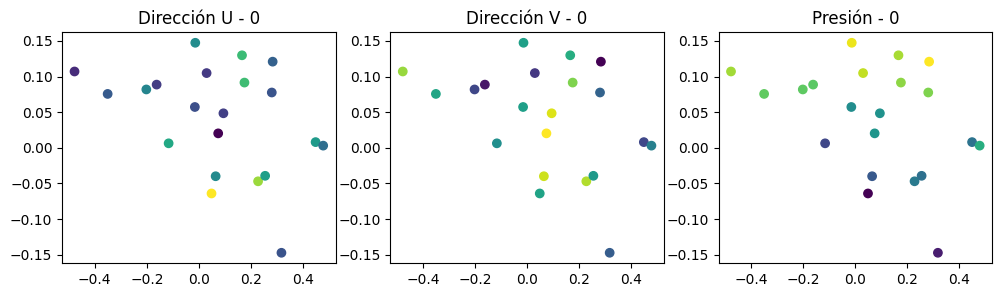

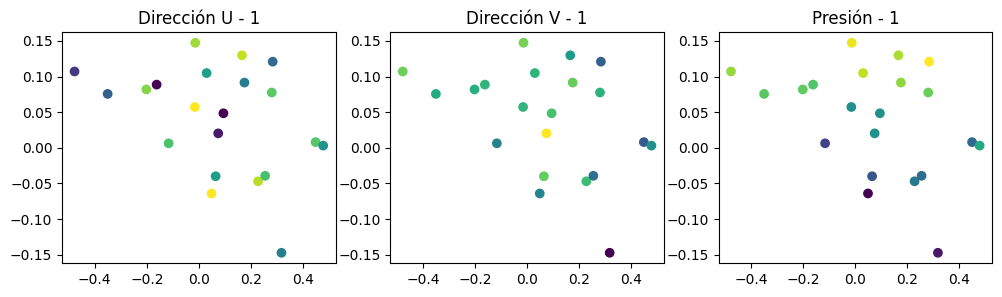

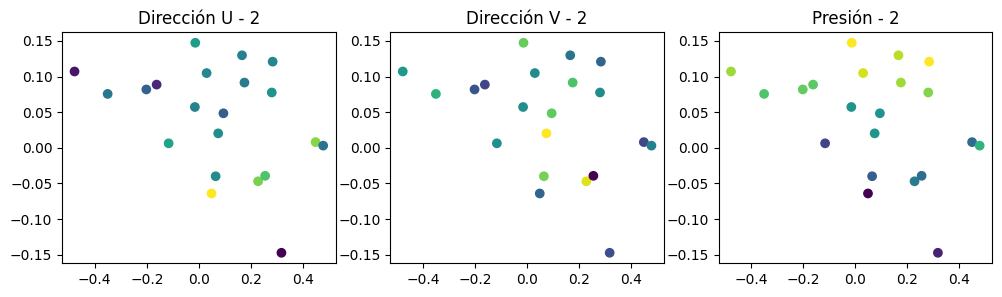

In [42]:
sec = range(T_WS.shape[1]) 
sec = range(3) 
X = X_WS[:,0] 
Y = Y_WS[:,0] 
for t in sec: 
    U = U_WS[:,t] 
    V = V_WS[:,t] 
    P = P_WS[:,t] 
    fig, ax = plt.subplots(1, 3, figsize=(12,3)) 
    ax[0].scatter(X, Y, c = ((1 + np.sin(U))/2)) 
    ax[0].set_title(f"Dirección U - {t}", ) 
    
    ax[1].scatter(X, Y, c = ((1 + np.sin(V))/2)) 
    ax[1].set_title(f"Dirección V - {t}", ) 
    
    ax[2].scatter(X, Y, c = ((1 + np.sin(P))/2)) 
    ax[2].set_title(f"Presión - {t}", ) 
    plt.show()


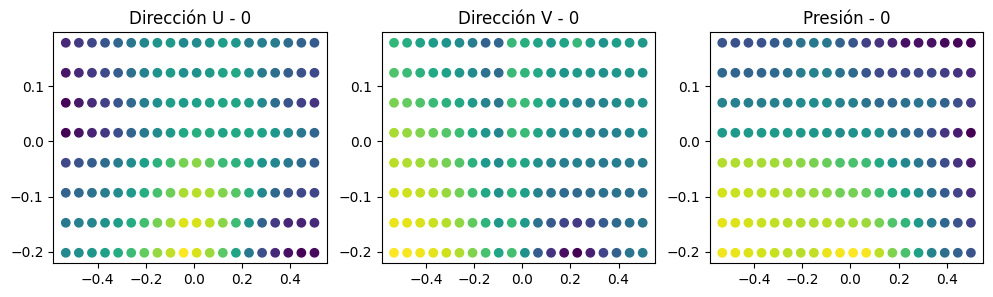

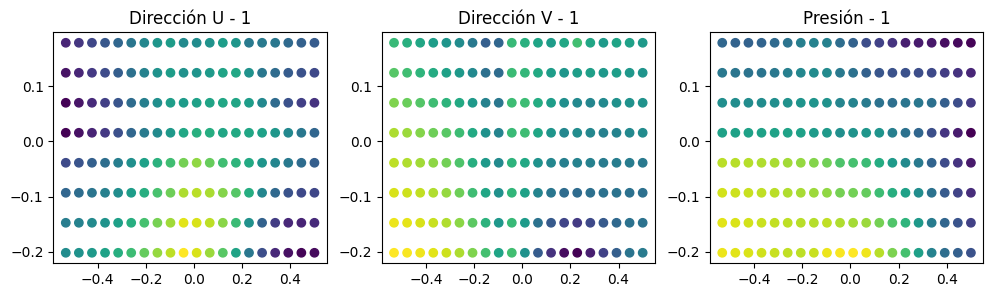

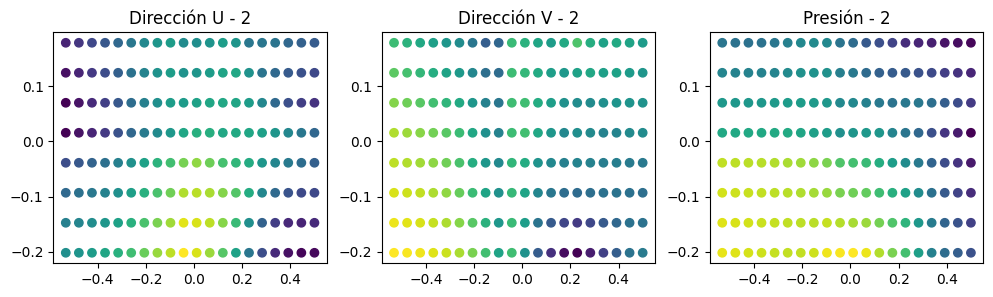

In [43]:
sec = range(T_PINN.shape[1]) 
sec = range(3) 
X = X_PINN[:,0]
Y = Y_PINN[:,0]
for t in sec: 
    U = U_PINN[:,t] 
    V = V_PINN[:,t] 
    P = P_PINN[:,t] 
    fig, ax = plt.subplots(1, 3, figsize=(12,3)) 
    ax[0].scatter(X, Y, c = ((1 + np.sin(U))/2)) 
    ax[0].set_title(f"Dirección U - {t}", ) 
    
    ax[1].scatter(X, Y, c = ((1 + np.sin(V))/2)) 
    ax[1].set_title(f"Dirección V - {t}", ) 
    
    ax[2].scatter(X, Y, c = ((1 + np.sin(P))/2)) 
    ax[2].set_title(f"Presión - {t}", ) 
    plt.show()


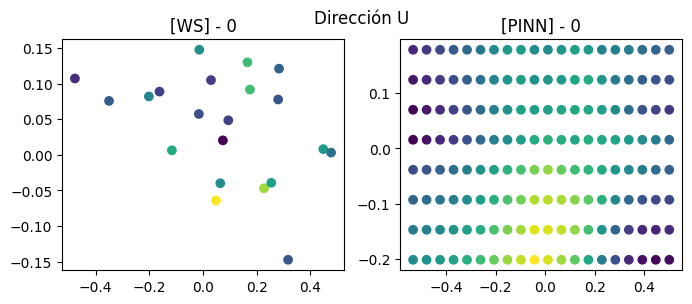

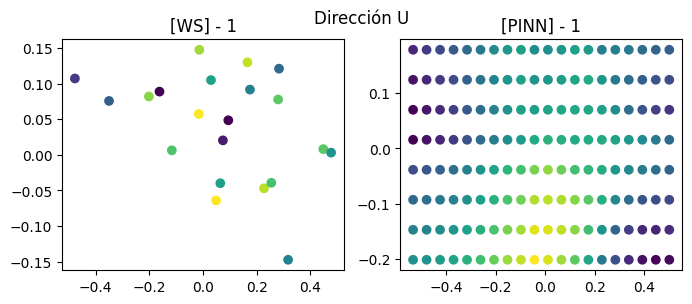

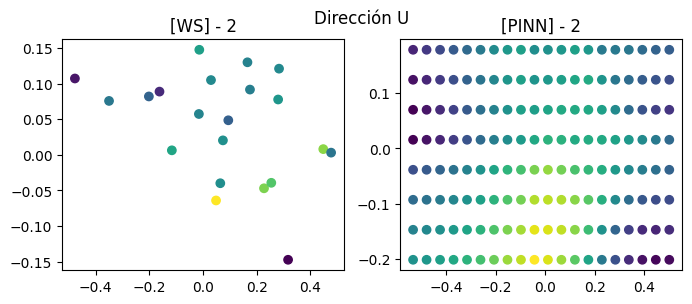

In [44]:
sec = range(T_WS.shape[1]) 
sec = range(3) 
x_ws = X_WS[:,0]
y_ws = Y_WS[:,0]

x_pinn = X_PINN[:,0] 
y_pinn = Y_PINN[:,0] 
for t in sec: 
    u_ws = U_WS[:,t] 
    v_ws = V_WS[:,t] 
    p_ws = P_WS[:,t] 

    u_pinn = U_PINN[:,t] 
    v_pinn = V_PINN[:,t] 
    p_pinn = P_PINN[:,t] 

    fig, ax = plt.subplots(1, 2, figsize=(8,3)) 
    ax[0].scatter(x_ws, y_ws, c = u_ws) 
    ax[0].set_title(f"[WS] - {t}", ) 
    
    ax[1].scatter(x_pinn, y_pinn, c = u_pinn) 
    ax[1].set_title(f"[PINN] - {t}", ) 

    fig.suptitle("Dirección U")
  
    plt.show()

In [45]:
sec = range(T_WS.shape[1]) 
sec = range(3) 

X_PINN[:,0].shape
x_pinn = X_PINN[:,0].reshape(20,8)
y_pinn = Y_PINN[:,0].reshape(20,8)
u_pinn = U_PINN[:,0].reshape(20,8)
v_pinn = V_PINN[:,0].reshape(20,8)
p_pinn = P_PINN[:,0].reshape(20,8)

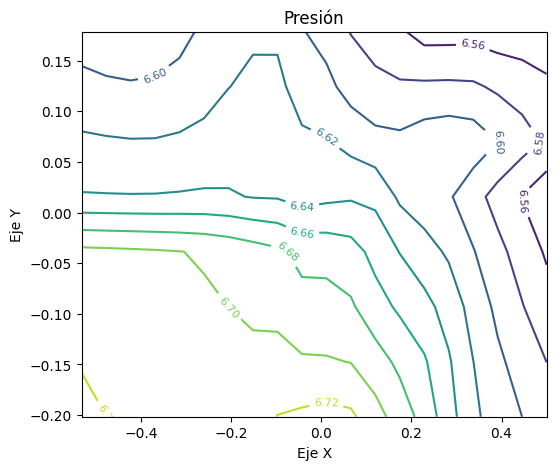

In [46]:
def grafica_nivel(x, y, z, title, levels=10, fill=True, figsize=(6,5)):
    plt.figure(figsize=figsize)
    if fill:
        plt.contourf(x, y, z, levels=levels, cmap="plasma")            # contorno con relleno
        plt.colorbar(label=title)
    else:
        contour = plt.contour(x, y, z, levels=levels, cmap="viridis")  # líneas de contorno
        plt.clabel(contour, inline=True, fontsize=8)               # etiquetas en las curvas
    plt.title(title)
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    ...
    
grafica_nivel(x_pinn, y_pinn, p_pinn, "Presión", fill=False)

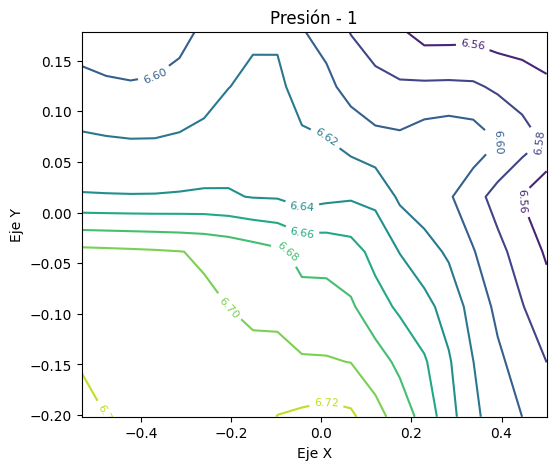

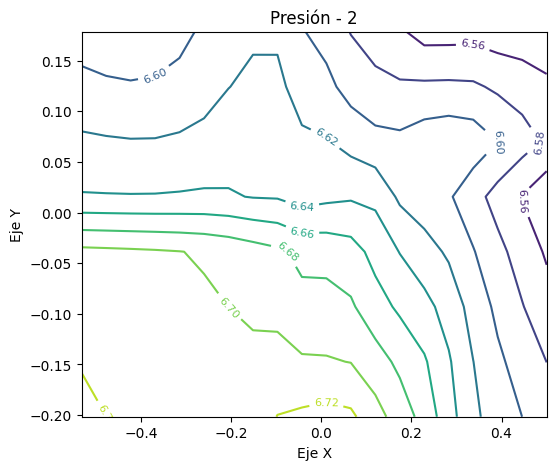

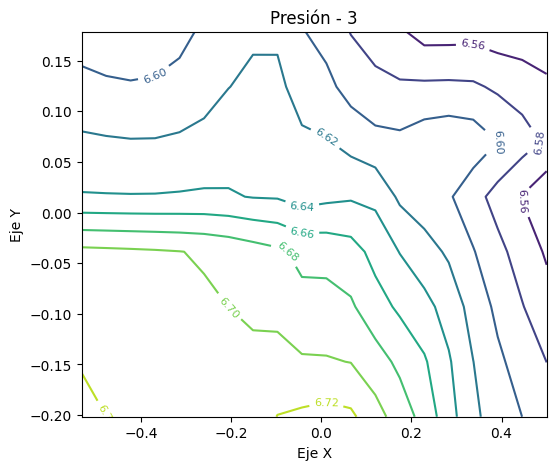

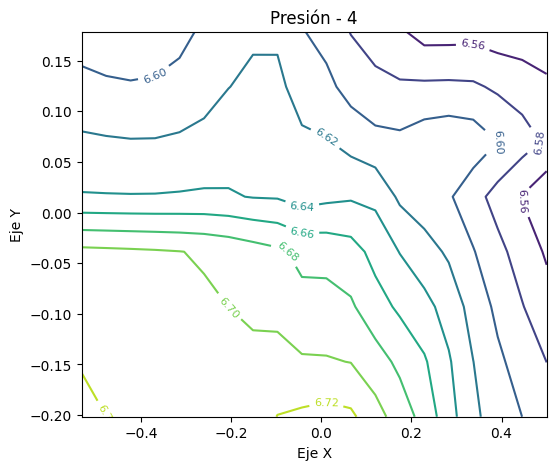

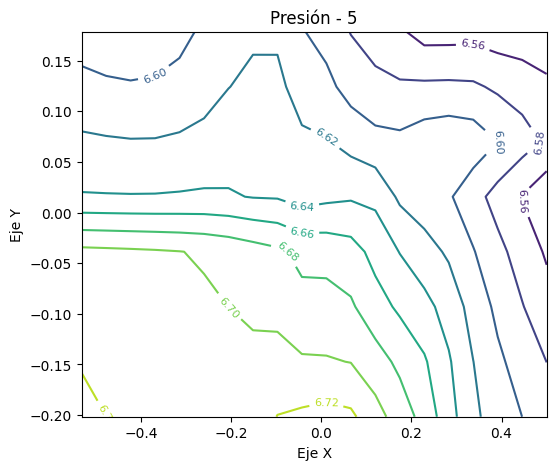

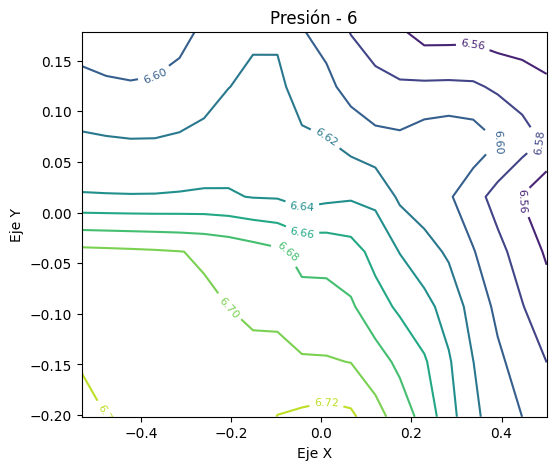

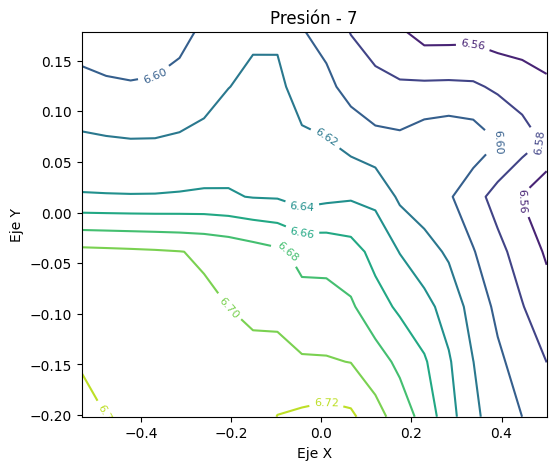

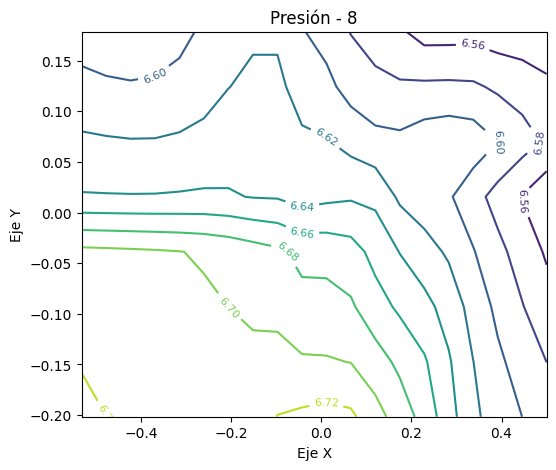

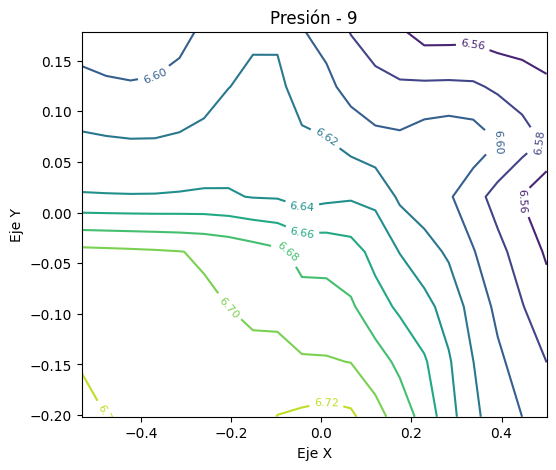

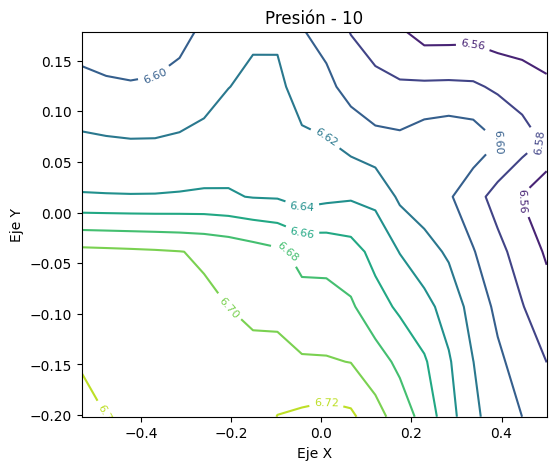

In [47]:
sec = range(T_WS.shape[1]) 
sec = range(10) 

x_pinn = X_PINN[:,0].reshape(20,8)
y_pinn = Y_PINN[:,0].reshape(20,8)

def grafica_nivel(x, y, z, title, levels=10, fill=True, figsize=(6,5)):
    plt.figure(figsize=figsize)
    if fill:
        plt.contourf(x, y, z, levels=levels, cmap="plasma")            # contorno con relleno
        plt.colorbar(label=title)
    else:
        contour = plt.contour(x, y, z, levels=levels, cmap="viridis")  # líneas de contorno
        plt.clabel(contour, inline=True, fontsize=8)               # etiquetas en las curvas
    plt.title(title)
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    ...
    

for t in sec:
    p_pinn = P_PINN[:,0].reshape(20,8)
    grafica_nivel(x_pinn, y_pinn, p_pinn, f"Presión - {t + 1}", fill=False)
    ...

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Tus datos/base ---
# sec = range(10)
sec = range(T_WS.shape[1])

# Mallas X, Y (formato 2D 20x8)
x_pinn = X_PINN[:, 0].reshape(20, 8)
y_pinn = Y_PINN[:, 0].reshape(20, 8)

# --- Configuración de niveles/cmap GLOBAL para evitar "saltos" de color entre frames ---
vmin = np.min([P_PINN[:, t] for t in sec])
vmax = np.max([P_PINN[:, t] for t in sec])
levels = 20  # o una lista de niveles si lo prefieres

# --- Figura y ejes (¡no crear nuevas figuras dentro del frame!) ---
fig, ax = plt.subplots(figsize=(8, 3))

def draw_frame(t):
    ax.clear()  # limpiamos el eje
    z = P_PINN[:, t].reshape(20, 8)

    cs = ax.contourf(x_pinn, y_pinn, z, levels=levels, cmap="plasma")#, vmin=vmin, vmax=vmax)
    # Barra de color: para que no se duplique, la creamos solo si no existe
    if not hasattr(draw_frame, "cbar"):
        draw_frame.cbar = fig.colorbar(cs, ax=ax, label="Presión")

    ax.set_title(f"Presión [{t+1:4}]")
    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.grid(True, alpha=0.3)
    return []  # sin artistas para blit

ani = animation.FuncAnimation(fig, draw_frame, frames=len(sec), interval=200, blit=False)

# Guardar a GIF (requiere Pillow)
ani.save("presion_pinn.gif", writer=animation.PillowWriter(fps=5), dpi=120)
plt.close(fig)


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Tus datos/base ---
# sec = range(10)
sec = range(T_WS.shape[1])

# Mallas X, Y (formato 2D 20x8)
x_pinn = X_PINN[:, 0].reshape(20, 8)
y_pinn = Y_PINN[:, 0].reshape(20, 8)

# --- Configuración de niveles/cmap GLOBAL para evitar "saltos" de color entre frames ---
vmin = np.min([P_PINN[:, t] for t in sec])
vmax = np.max([P_PINN[:, t] for t in sec])
levels = 20  # o una lista de niveles si lo prefieres

# --- Figura y ejes (¡no crear nuevas figuras dentro del frame!) ---
fig, ax = plt.subplots(figsize=(8, 3))

def draw_frame(t):
    ax.clear()  # limpiamos el eje
    z = U_PINN[:, t].reshape(20, 8)

    cs = ax.contourf(x_pinn, y_pinn, z, levels=levels, cmap="plasma")#, vmin=vmin, vmax=vmax)
    # Barra de color: para que no se duplique, la creamos solo si no existe
    if not hasattr(draw_frame, "cbar"):
        draw_frame.cbar = fig.colorbar(cs, ax=ax, label="Vel. U")

    ax.set_title(f"Vel. U [{t+1:4}]")
    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.grid(True, alpha=0.3)
    return []  # sin artistas para blit

ani = animation.FuncAnimation(fig, draw_frame, frames=len(sec), interval=200, blit=False)

# Guardar a GIF (requiere Pillow)
ani.save("u_pinn.gif", writer=animation.PillowWriter(fps=5), dpi=120)
plt.close(fig)


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Tus datos/base ---
# sec = range(10)
sec = range(T_WS.shape[1])

# Mallas X, Y (formato 2D 20x8)
x_pinn = X_PINN[:, 0].reshape(20, 8)
y_pinn = Y_PINN[:, 0].reshape(20, 8)

# --- Configuración de niveles/cmap GLOBAL para evitar "saltos" de color entre frames ---
vmin = np.min([P_PINN[:, t] for t in sec])
vmax = np.max([P_PINN[:, t] for t in sec])
levels = 20  # o una lista de niveles si lo prefieres

# --- Figura y ejes (¡no crear nuevas figuras dentro del frame!) ---
fig, ax = plt.subplots(figsize=(8, 3))

def draw_frame(t):
    ax.clear()  # limpiamos el eje
    z = V_PINN[:, t].reshape(20, 8)

    cs = ax.contourf(x_pinn, y_pinn, z, levels=levels, cmap="plasma")#, vmin=vmin, vmax=vmax)
    # Barra de color: para que no se duplique, la creamos solo si no existe
    if not hasattr(draw_frame, "cbar"):
        draw_frame.cbar = fig.colorbar(cs, ax=ax, label="Vel. V")

    ax.set_title(f"Vel. V [{t+1:4}]")
    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.grid(True, alpha=0.3)
    return []  # sin artistas para blit

ani = animation.FuncAnimation(fig, draw_frame, frames=len(sec), interval=200, blit=False)

# Guardar a GIF (requiere Pillow)
ani.save("v_pinn.gif", writer=animation.PillowWriter(fps=5), dpi=120)
plt.close(fig)
